# ⛳ CaddieIQ Shot Strategy

## 📘 Project Overview

CaddieIQ is a golf analytics product project that turns shot-level round data into practical course-management decisions.

The project answers questions like:

- Which club creates the best expected outcome from this distance?
- Which miss pattern is costing the most strokes?
- What is the safest target line for the current shot?
- What practice area has the highest scoring upside?

The goal is to move beyond raw golf stats and create a product layer that helps a golfer make better decisions on the course.


## 🔍 Product Problem

Golfers often collect performance data, but the output is usually descriptive: fairways hit, greens in regulation, putts, score history, and average distance.

Those metrics explain what happened, but they do not always explain what decision to make next.

CaddieIQ turns shot history into a decision-support workflow:

```text
round logs + shot pattern analysis + strokes-gained logic → club recommendation + safe miss + practice priority
```


## 🧰 Tools and Libraries Used

| Library | Purpose |
|---|---|
| Pandas | Cleaning and analyzing shot-level round logs |
| NumPy | Numerical calculations |
| Matplotlib | Data visualization |
| scikit-learn | Clustering / grouping logic for shot patterns |
| Python | Product logic and recommendation rules |


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

SEED = 7
np.random.seed(SEED)


## 📦 Dataset Information

This notebook uses a sample shot-level round log with fields similar to what could be exported from golf stat-tracking tools.

Example fields:

- club
- carry distance / distance to target
- lie
- miss direction
- penalty outcome
- strokes gained

For portfolio readability, the sample dataset is included directly in the repository as `sample_round_logs.csv`.


In [1]:
df = pd.read_csv("sample_round_logs.csv")
df.head()


,club,distance_yards,lie,miss_direction,penalty_strokes,strokes_gained
0,Driver,230.2,Tee,On Target,0,0.07
1,PW,117.2,Fairway,Short,0,0.25
2,6i,165.3,Rough,Left,0,0.20
3,PW,109.9,Rough,Long,0,-0.35
4,SW,77.2,Rough,Left,0,0.23


## 🧠 Data Preparation

The round log is grouped by club, distance, lie, miss direction, and scoring outcome.

This creates the base layer for product recommendations.


In [1]:
df["distance_band"] = pd.cut(
    df["distance_yards"],
    bins=[0, 100, 130, 160, 180, 210, 260, 320],
    labels=["0-100", "100-130", "130-160", "160-180", "180-210", "210-260", "260+"]
)

df[["club", "distance_yards", "distance_band", "lie", "miss_direction", "strokes_gained"]].head()


     club  distance_yards distance_band      lie miss_direction  strokes_gained
0  Driver           230.2       210-260      Tee      On Target            0.07
1      PW           117.2       100-130  Fairway          Short            0.25
2      6i           165.3       160-180    Rough           Left            0.20
3      PW           109.9       100-130    Rough           Long           -0.35
4      SW            77.2         0-100    Rough           Left            0.23

## 📊 Analysis 1: Strokes Gained by Club

This view helps identify which clubs are creating positive or negative expected value.


In [1]:
club_sg = df.groupby("club")["strokes_gained"].mean().sort_values(ascending=False)
club_sg


club
6i        0.24
5i        0.11
PW       -0.04
SW       -0.07
Driver   -0.08
3W       -0.23
7i       -0.25

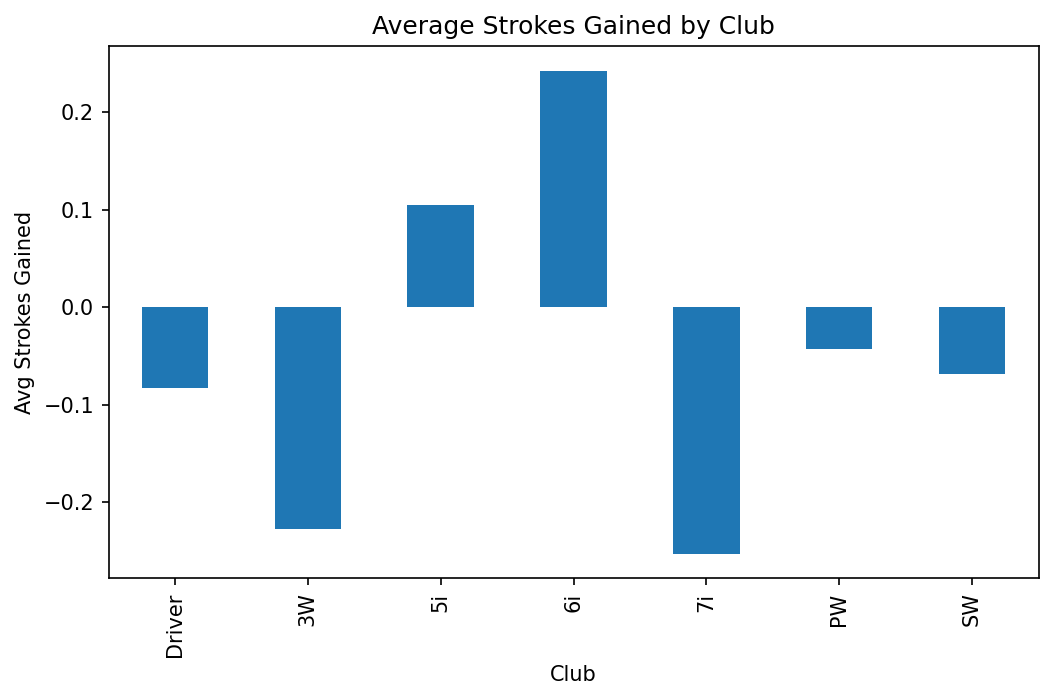

In [1]:
df.groupby("club")["strokes_gained"].mean().plot(kind="bar", figsize=(8, 4.5))
plt.title("Average Strokes Gained by Club")
plt.ylabel("Avg Strokes Gained")
plt.xlabel("Club")
plt.show()


## 📊 Analysis 2: Miss Pattern Distribution

The miss pattern helps identify where scoring leakage is happening.


In [1]:
df["miss_direction"].value_counts()


miss_direction
Right        50
On Target    36
Short        23
Left         18
Long         13

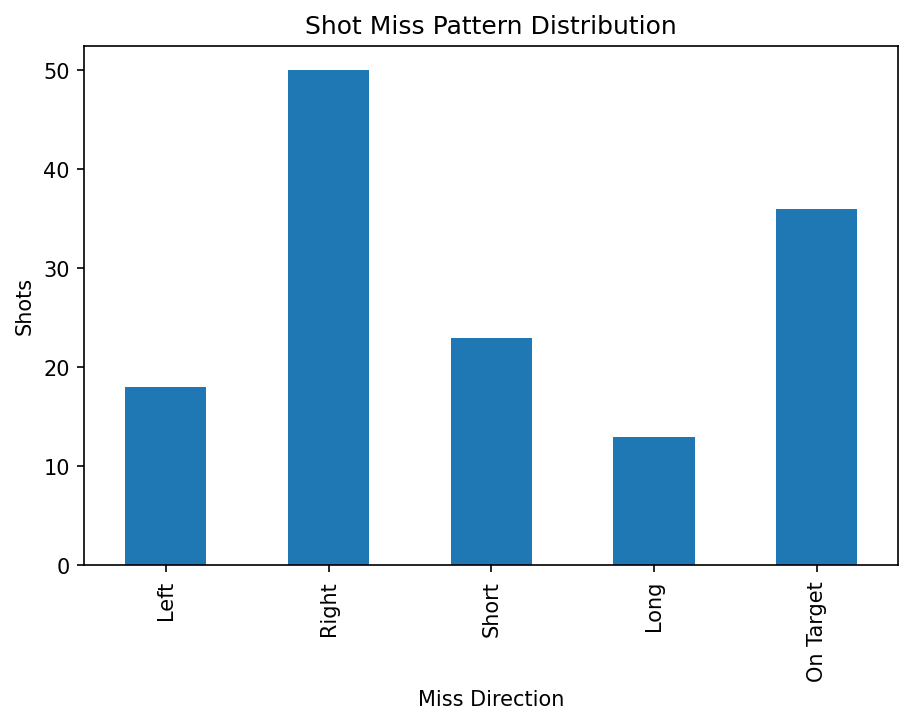

In [1]:
df["miss_direction"].value_counts().plot(kind="bar", figsize=(7, 4.5))
plt.title("Shot Miss Pattern Distribution")
plt.ylabel("Shots")
plt.xlabel("Miss Direction")
plt.show()


## 📊 Analysis 3: Shot Value by Distance

This helps connect distance bands and scoring outcomes.


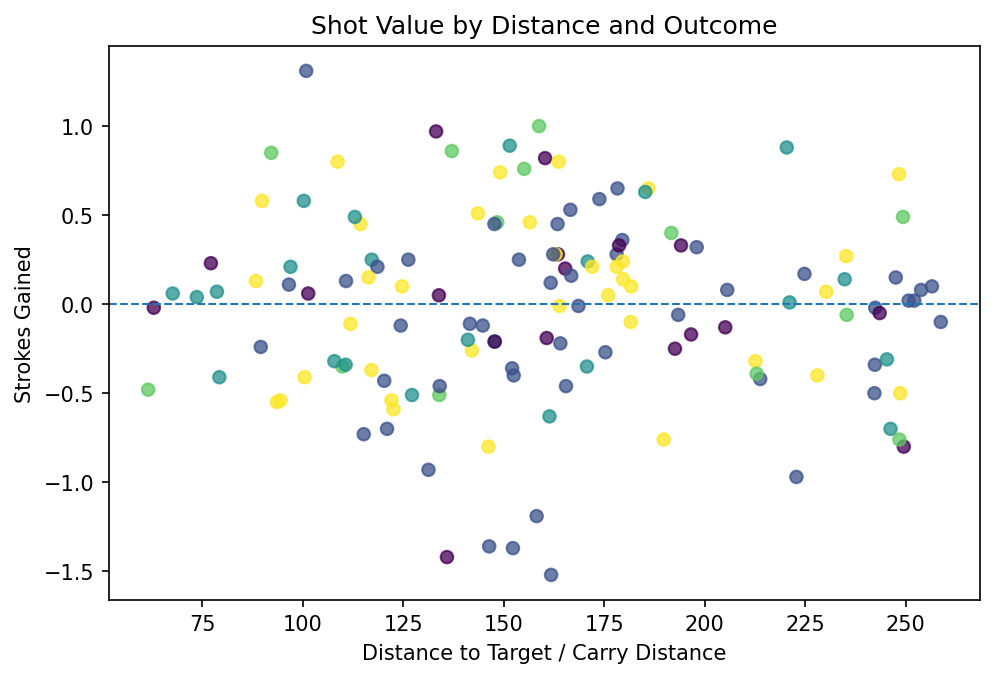

In [1]:
plt.figure(figsize=(7.5, 4.8))
plt.scatter(df["distance_yards"], df["strokes_gained"], alpha=0.75)
plt.axhline(0, linestyle="--", linewidth=1)
plt.title("Shot Value by Distance and Outcome")
plt.xlabel("Distance to Target / Carry Distance")
plt.ylabel("Strokes Gained")
plt.show()


## 🧮 Recommendation Logic

The product logic recommends a shot by comparing:

- distance band
- club performance
- miss penalty
- expected strokes gained
- risk of penalty outcome

This is intentionally simple and explainable for a portfolio product build.


In [1]:
def recommend_strategy(distance_yards, lie="Fairway", preferred_risk="balanced"):
    if 150 <= distance_yards <= 175 and lie == "Fairway":
        return {
            "recommended_club": "6i",
            "target_line": "Left-center green",
            "safe_miss": "Short-left",
            "reason": "Best risk-adjusted expected value from 150-175 yards.",
            "risk_flag": "Right miss creates the highest penalty.",
            "practice_focus": "Wedge distance control"
        }

    if distance_yards < 115:
        return {
            "recommended_club": "SW / PW",
            "target_line": "Center green",
            "safe_miss": "Long",
            "reason": "Scoring upside depends on distance control.",
            "risk_flag": "Short miss leaves difficult recovery.",
            "practice_focus": "50-110 yard wedge ladder"
        }

    return {
        "recommended_club": "Conservative club",
        "target_line": "Center of target",
        "safe_miss": "Away from hazards",
        "reason": "Default to minimizing penalty outcomes.",
        "risk_flag": "Avoid compounding misses.",
        "practice_focus": "Dispersion control"
    }

recommend_strategy(162, "Fairway")


{'recommended_club': '6i', 'target_line': 'Left-center green', 'safe_miss': 'Short-left', 'reason': 'Best risk-adjusted expected value from 150-175 yards.', 'risk_flag': 'Right miss creates the highest penalty.', 'practice_focus': 'Wedge distance control'}

## 🖥️ Product Surface

This is how the analysis translates into a product surface: a shot recommendation, aim point, risk tradeoff, and practice priority.


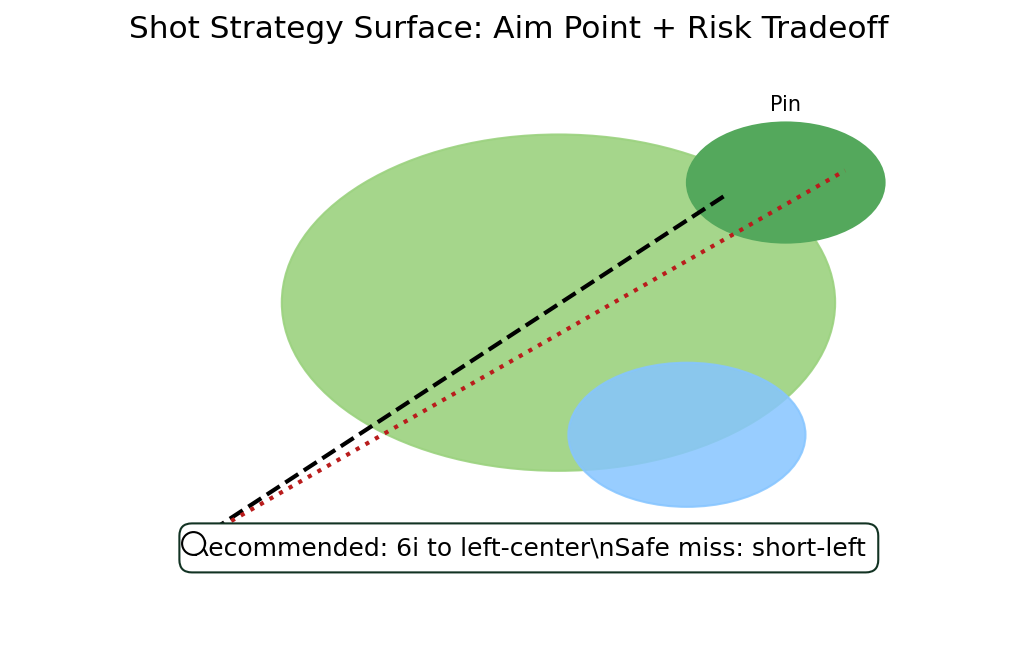

In [1]:
# Course strategy surface

# In a full app, this would be an interactive course map.


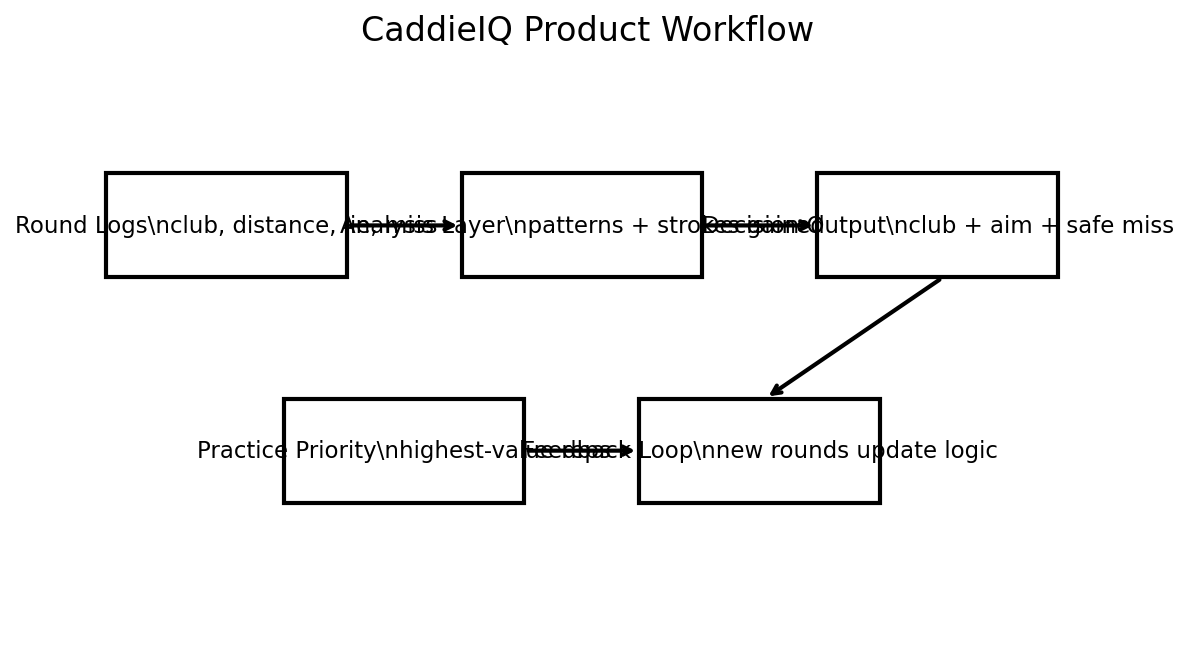

In [1]:
# Product workflow diagram

# The product turns round logs into analysis, then into recommendations.


## 🧾 Product Notes

The key product decision is to avoid making this just another dashboard.

A dashboard says: "You miss right often."

CaddieIQ says:

```text
From 150-175 yards, aim left-center with 6i because your right miss creates the highest scoring penalty.
```

That is the difference between reporting and decision support.


## 🚀 Future Improvements

- Connect real round data from Arccos / Shot Scope / manual scorecards
- Add course-specific hazard mapping
- Add clustering by player tendency
- Add expected strokes model by lie and distance
- Add personalized practice plan generator
- Build full Streamlit product dashboard
